In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

In [2]:
sentences = [
    "I love machine learning.",
    "I enjoy studying AI.",
    "Deep learning is fascinating.",
    "Pizza tastes delicious.",
    "Traveling is fun.",
]

for idx, sentence in enumerate(sentences, start=1):
    print(f"S{idx}: {sentence}")

S1: I love machine learning.
S2: I enjoy studying AI.
S3: Deep learning is fascinating.
S4: Pizza tastes delicious.
S5: Traveling is fun.


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

tfidf_matrix = tfidf.fit_transform(sentences)

print("TF-IDF Matrix Shape:")

print(tfidf_matrix.shape)

TF-IDF Matrix Shape:
(5, 14)


In [4]:
tfidf_similarity = cosine_similarity(tfidf_matrix, tfidf_matrix)

tfidf_similarity

array([[1.        , 0.        , 0.22001359, 0.        , 0.        ],
       [0.        , 1.        , 0.        , 0.        , 0.        ],
       [0.22001359, 0.        , 1.        , 0.        , 0.22001359],
       [0.        , 0.        , 0.        , 1.        , 0.        ],
       [0.        , 0.        , 0.22001359, 0.        , 1.        ]])

In [5]:
tfidf_df = pd.DataFrame(
    tfidf_similarity,
    columns=[f"S{i+1}" for i in range(len(sentences))],
    index=[f"S{i+1}" for i in range(len(sentences))],
)

tfidf_df.round(2)

,S1,S2,S3,S4,S5
S1,1.00,0.0,0.22,0.0,0.00
S2,0.00,1.0,0.00,0.0,0.00
S3,0.22,0.0,1.00,0.0,0.22
S4,0.00,0.0,0.00,1.0,0.00
S5,0.00,0.0,0.22,0.0,1.00


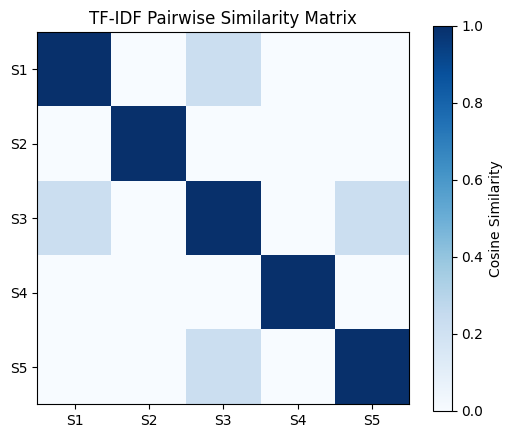

In [6]:
plt.figure(figsize=(6, 5))

plt.imshow(tfidf_similarity, cmap="Blues")

plt.colorbar(label="Cosine Similarity")

plt.xticks(range(len(sentences)), [f"S{i+1}" for i in range(len(sentences))])

plt.yticks(range(len(sentences)), [f"S{i+1}" for i in range(len(sentences))])

plt.title("TF-IDF Pairwise Similarity Matrix")

plt.show()

In [7]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

embeddings = model.encode(sentences)

print(embeddings.shape)

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange
d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


(5, 384)


In [8]:
sbert_similarity = cosine_similarity(embeddings, embeddings)

sbert_df = pd.DataFrame(
    sbert_similarity,
    columns=[f"S{i+1}" for i in range(len(sentences))],
    index=[f"S{i+1}" for i in range(len(sentences))],
)

sbert_df.round(2)

,S1,S2,S3,S4,S5
S1,1.00,0.55,0.68,0.20,0.22
S2,0.55,1.00,0.46,0.08,0.33
S3,0.68,0.46,1.00,0.09,0.28
S4,0.20,0.08,0.09,1.00,0.18
S5,0.22,0.33,0.28,0.18,1.00


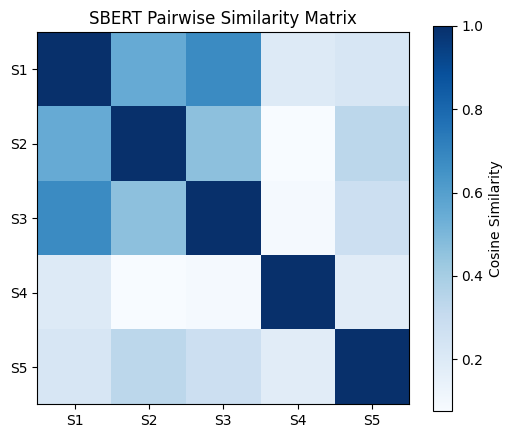

In [9]:
plt.figure(figsize=(6, 5))

plt.imshow(sbert_similarity, cmap="Blues")

plt.colorbar(label="Cosine Similarity")

plt.xticks(range(len(sentences)), [f"S{i+1}" for i in range(len(sentences))])

plt.yticks(range(len(sentences)), [f"S{i+1}" for i in range(len(sentences))])

plt.title("SBERT Pairwise Similarity Matrix")

plt.show()

In [11]:
def build_similarity_matrix(embeddings, labels=None):

    matrix = cosine_similarity(embeddings, embeddings)

    if labels is None:
        labels = [f"S{i+1}" for i in range(len(matrix))]

    return pd.DataFrame(matrix, columns=labels, index=labels)

In [12]:
similarity_df = build_similarity_matrix(embeddings)

similarity_df.round(2)

,S1,S2,S3,S4,S5
S1,1.00,0.55,0.68,0.20,0.22
S2,0.55,1.00,0.46,0.08,0.33
S3,0.68,0.46,1.00,0.09,0.28
S4,0.20,0.08,0.09,1.00,0.18
S5,0.22,0.33,0.28,0.18,1.00


In [13]:
matrix = sbert_similarity.copy()

np.fill_diagonal(matrix, -1)

row, col = np.unravel_index(np.argmax(matrix), matrix.shape)

print("Most Similar Pair:\n")

print(f"S{row+1}: {sentences[row]}")

print(f"S{col+1}: {sentences[col]}")

print("\nSimilarity:", round(matrix[row, col], 3))

Most Similar Pair:

S1: I love machine learning.
S3: Deep learning is fascinating.

Similarity: 0.679


In [15]:
while True:

    print("\nAvailable Sentences:\n")

    for idx, s in enumerate(sentences):
        print(f"{idx}: {s}")

    choice = input("\nEnter sentence number (or quit): ")

    if choice.lower() == "quit":
        break

    idx = int(choice)

    similarities = sbert_similarity[idx]

    result = pd.DataFrame({"Sentence": sentences, "Similarity": similarities})

    result = result.sort_values(by="Similarity", ascending=False)

    print("\nMost Similar Sentences:\n")
    print(result)


Available Sentences:

0: I love machine learning.
1: I enjoy studying AI.
2: Deep learning is fascinating.
3: Pizza tastes delicious.
4: Traveling is fun.

Most Similar Sentences:

                        Sentence  Similarity
1           I enjoy studying AI.    1.000000
0       I love machine learning.    0.551479
2  Deep learning is fascinating.    0.461758
4              Traveling is fun.    0.333807
3        Pizza tastes delicious.    0.076538

Available Sentences:

0: I love machine learning.
1: I enjoy studying AI.
2: Deep learning is fascinating.
3: Pizza tastes delicious.
4: Traveling is fun.


ValueError: invalid literal for int() with base 10: ''